In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv('winequality-red.csv')

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.columns.to_list()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
df.nunique() # Checking duplicate values (give unique value column)

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

# Univariate analysis (quality column)

In [10]:
quality_counts = df['quality'].value_counts()
quality_counts

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## 1. Quality Distribution (Count Plot)

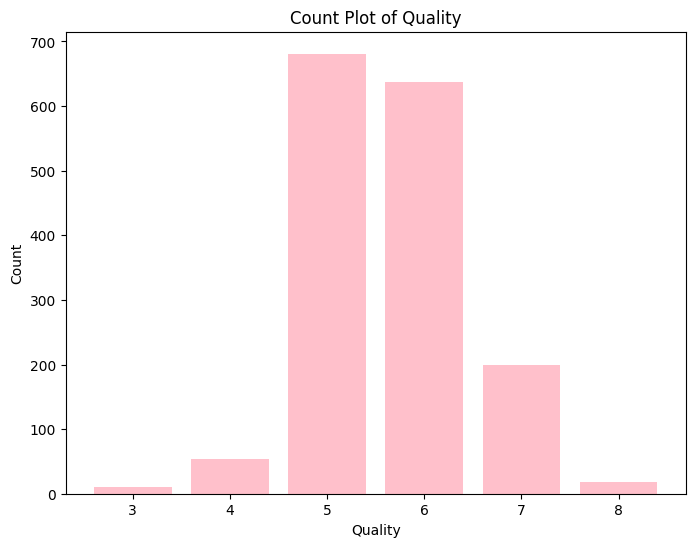

In [11]:
plt.figure(figsize=(8,6))
plt.bar(quality_counts.index,quality_counts,color='pink')
plt.title("Count Plot of Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

- Most wines fall in quality 5 and 6
- Very few wines have high quality (7 or above)

## 2. Alcohol vs Quality (Swam plot)

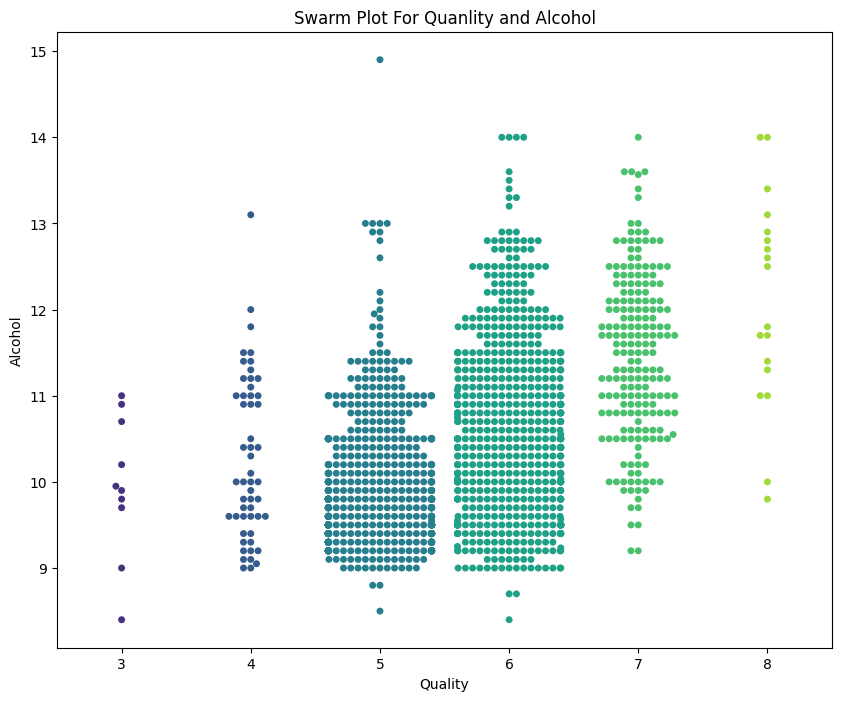

In [12]:
plt.figure(figsize=(10,8))
sns.swarmplot(x="quality",y='alcohol',data=df,palette='viridis')
plt.title("Swarm Plot For Quanlity and Alcohol")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

## 2. Alcohol vs Quality (Scatter plot)

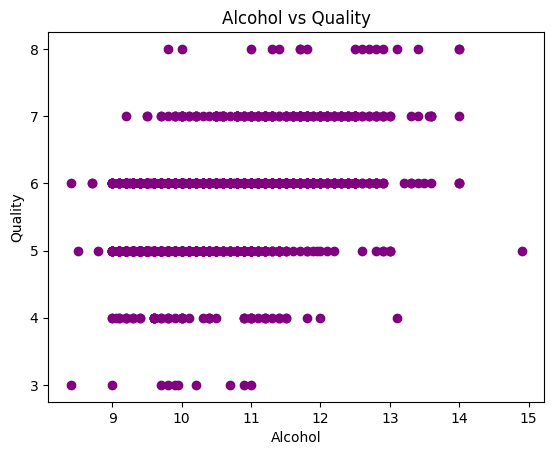

In [48]:
plt.figure()
plt.scatter(df['alcohol'], df['quality'],color='purple')
plt.title("Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

- Higher alcohol content generally leads to better quality
- Shows positive correlation

## 3. Violin Plot For Quanlity and Alcohol

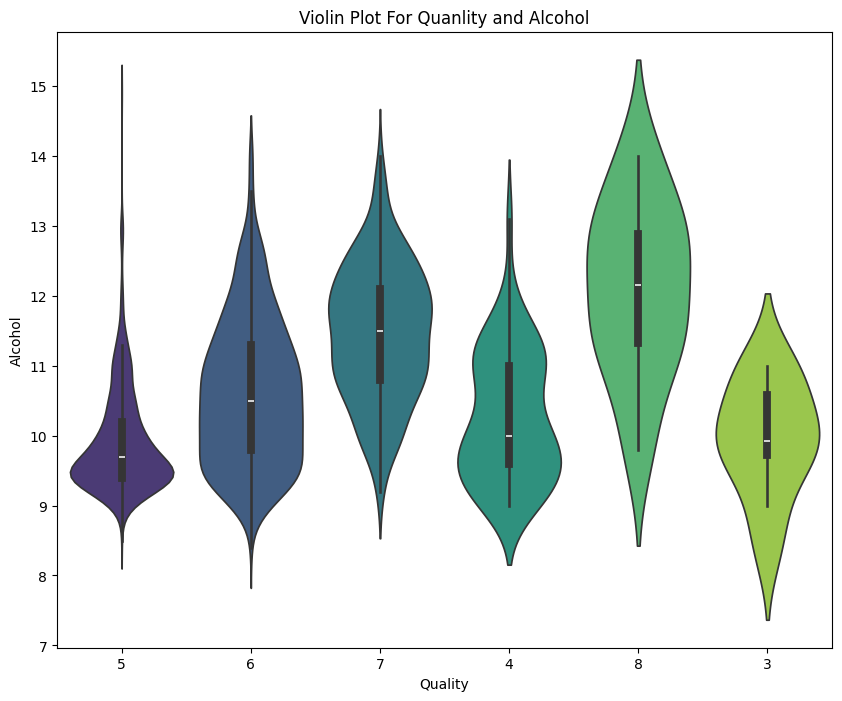

In [13]:
df['quality'] = df['quality'].astype(str)
plt.figure(figsize=(10,8))
sns.violinplot(x="quality",y='alcohol',data=df,palette='viridis')
plt.title("Violin Plot For Quanlity and Alcohol")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

## 4. Box Plot For Quanlity and Alcohol using seaborn

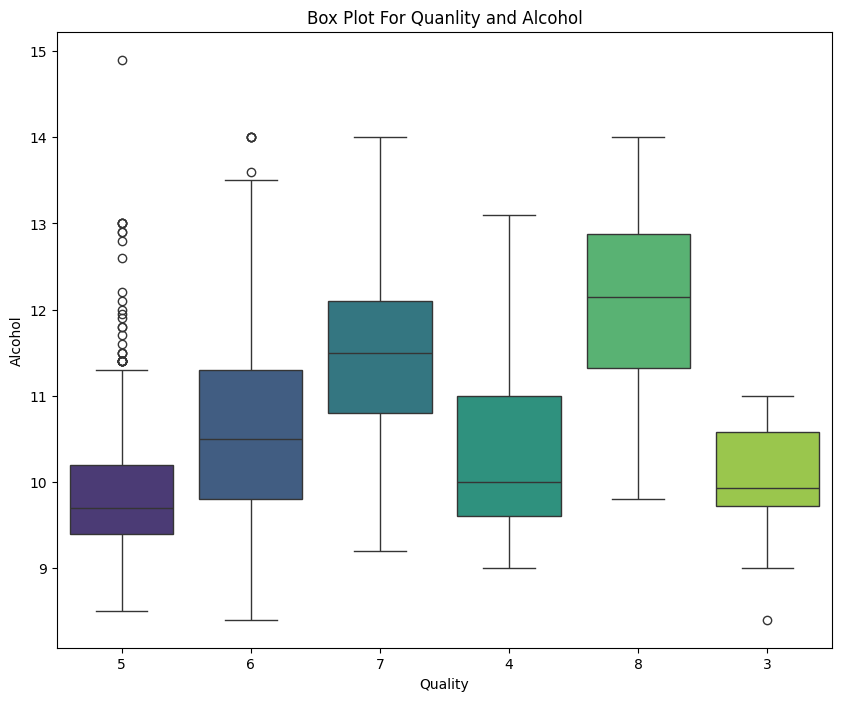

In [14]:
plt.figure(figsize=(10,8)) # line call whisker
sns.boxplot(x="quality",y='alcohol',data=df,palette='viridis')
plt.title("Box Plot For Quanlity and Alcohol")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

## 5. Correlation Heatmap using seaborn

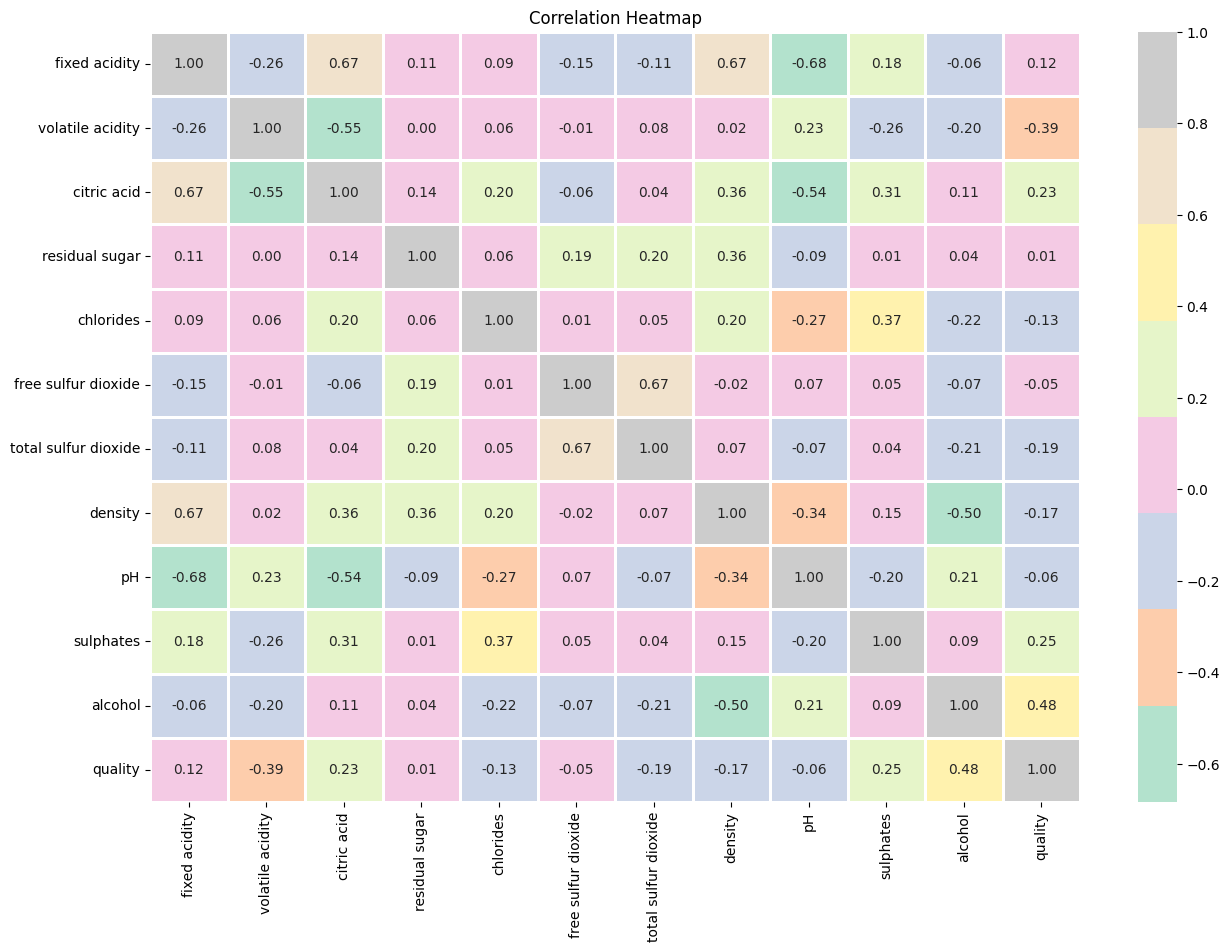

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='Pastel2',linewidths=2)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [17]:
duplicated = df.duplicated()
duplicated

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool

In [18]:
print("Number of duplicated instances : ",duplicated.sum())

Number of duplicated instances :  240


In [19]:
df[duplicated]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [20]:
df = df.drop_duplicates()

In [21]:
duplicated = df.duplicated()

In [22]:
duplicated

0       False
1       False
2       False
3       False
5       False
        ...  
1593    False
1594    False
1595    False
1597    False
1598    False
Length: 1359, dtype: bool

In [23]:
print("Number of duplicated instances : ",duplicated.sum())

Number of duplicated instances :  0


In [24]:
df[duplicated]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


In [25]:
df['quality'] = df['quality'].astype(int)

In [26]:
df['Quality_type1'] = 'bad'  # default
df.loc[df['quality'] >= 7, 'Quality_type'] = 'good'

In [27]:
df['quality_type'] = np.where(df['quality']>=7.0,'Good','Bad')

In [28]:
df['quality_type'].value_counts()

quality_type
Bad     1175
Good     184
Name: count, dtype: int64

## 6. pH Distribution

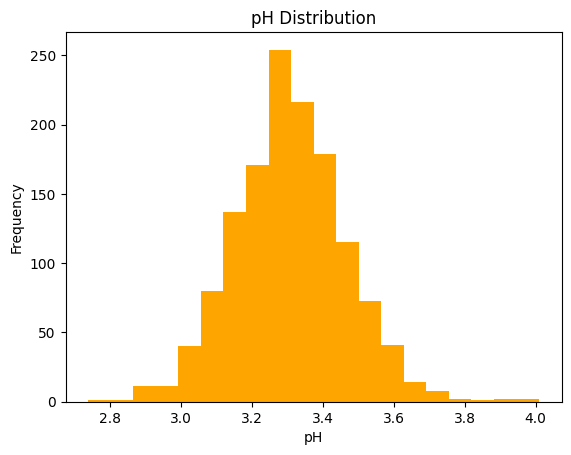

In [50]:
plt.figure()
df['pH'].plot(kind='hist', bins=20,color='Orange')
plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

- Most wines have pH between 3.2 – 3.4
- Indicates wines are slightly acidic

## 7. Volatile Acidity vs Quality

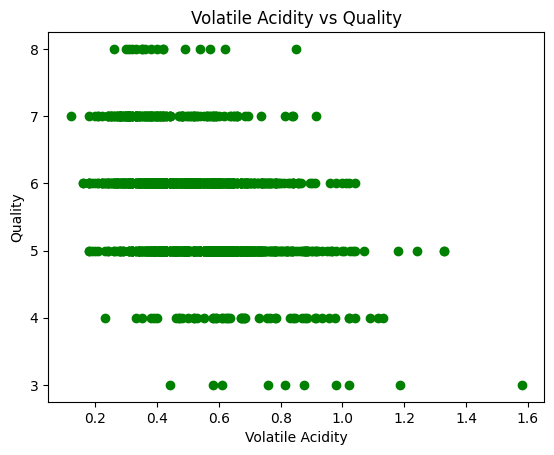

In [53]:
plt.figure()
plt.scatter(df['volatile acidity'], df['quality'],color='green')
plt.title("Volatile Acidity vs Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.show()

- Higher volatile acidity → lower quality
- Indicates inverse relationship

## 8. Residual Sugar Distribution

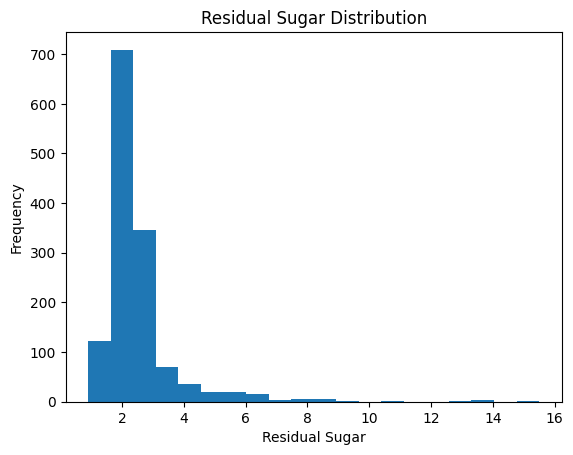

In [54]:
plt.figure()
df['residual sugar'].plot(kind='hist', bins=20)
plt.title("Residual Sugar Distribution")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

- Most wines have low sugar content
- Few wines are sweet

## 9. Distribution of Quality

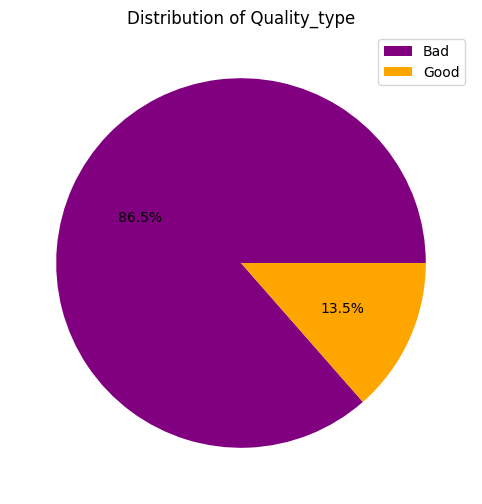

In [31]:
plt.figure(figsize=(10,6))
plt.pie(df['quality_type'].value_counts(),autopct='%1.1f%%',colors=['purple','orange'])
plt.title("Distribution of Quality_type")
plt.legend(['Bad','Good'])
plt.show()

- Major part of buisness come from good quality So Focus on good quality wine for the success of buisness

## 10. Density vs Alcohol

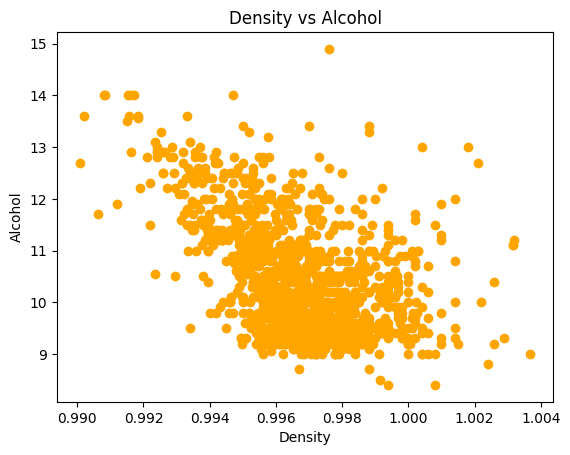

In [56]:
plt.figure()
plt.scatter(df['density'], df['alcohol'],color='orange')
plt.title("Density vs Alcohol")
plt.xlabel("Density")
plt.ylabel("Alcohol")
plt.show()

- Higher alcohol → lower density
- Shows inverse relationship

## 11. Chlorides vs Quality

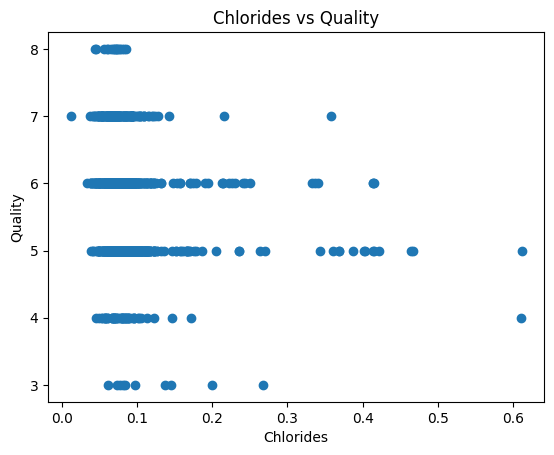

In [57]:
plt.figure()
plt.scatter(df['chlorides'], df['quality'])
plt.title("Chlorides vs Quality")
plt.xlabel("Chlorides")
plt.ylabel("Quality")
plt.show()

- Higher chlorides → lower quality wine